In [65]:
#import relevant libraries
import os
#from scipy import stats

import numpy as np
#import scipy as sp
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.cm
import seaborn as sns
import dabest
import NLCLIMB
import NLMATH
import itertools
from datetime import datetime
date = datetime.today().strftime('%Y%m%d')
from statistics import mean
from textwrap import wrap


import dabest
import plotly.express as px 
from plotly.subplots import make_subplots
import plotly.graph_objects as go
from plotly.graph_objects import Layout

#NOTE: SUPPRESSES WARNINGS!

import warnings


warnings.simplefilter(action="ignore", category=RuntimeWarning)
warnings.simplefilter(action="ignore", category=UserWarning)
warnings.simplefilter(action='ignore', category=pd.errors.PerformanceWarning)
warnings.simplefilter(action='ignore', category=FutureWarning)


In [66]:
#initial file processing
homecomp = "C:\\Users\\User"
filepath = "\\ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\eOPN3 manuscript\\Data compilation\\Together\\3. Compiled\\"
titledpath = homecomp
openPath = titledpath + filepath
files2 = os.listdir(openPath)

## Functions

In [71]:
def pergenotypeplotting(openPath, files2, k): 
    # input is a metric name
    metricname = pd.DataFrame()
    singlemeandiff= pd.DataFrame()
    
    for f in files2:
        samplefile = pd.DataFrame()
        singlemeans = pd.DataFrame()
        newfile2read = pd.read_csv(openPath + f, index_col=0)
        cross = f.replace(" allstats.csv", "")
        samplefile['bootstrap'] = newfile2read[k+"_bootstrap"]
        samplefile['deltag'] = newfile2read[k+"_deltag"]
        samplefile['Cross'] = cross.replace("[ATR]", "*").replace("eOPN3", "AsOPN3").replace("[B]", "").replace("(iii)M4", "")
        samplefile["metric"] = k
        
        singlemeans['mean'] = samplefile['deltag'].unique()
        singlemeans['cross'] = cross.replace("[ATR]", "*").replace("eOPN3", "AsOPN3").replace("[B]", "").replace("(iii)M4", "")
        singlemeans['err'] =  samplefile['bootstrap'].mean() - (samplefile['bootstrap'].mean() - 1.96*(np.std(samplefile['bootstrap'])))  #mean -bca_low (self calculated)

        metricname = pd.concat([metricname, samplefile], axis=0)
        singlemeandiff = pd.concat([singlemeandiff, singlemeans], axis=0)

    return metricname, singlemeandiff

def forestplot(metricname, singlemeandiff, colors):
    # Create a single figure with all violin plots
    fig, ax = plt.subplots(1, 1, figsize=(12, 8))
    
    # Get unique crosses and assign x positions
    unique_crosses = singlemeandiff['cross'].unique()
    n_crosses = len(unique_crosses)
    x_positions = range(n_crosses)
    
    # Define violin color
    violin_color = '#57EC3A'
    
    # Extract drivers and responders for each cross
    drivers = []
    responders = []
    for cross in unique_crosses:
        driver = cross.split(' ')[0]
        responder = cross.split(' ')[-1]
        drivers.append(driver)
        responders.append(responder)
    
    # Create vertical half violin plots for each cross
    for i, (cross, mean, err) in enumerate(zip(singlemeandiff['cross'], 
                                              singlemeandiff['mean'], 
                                              singlemeandiff['err'])):
        
        # Get bootstrap data for this cross
        cross_data = metricname[metricname['Cross'] == cross]['bootstrap']
        
        # Create violin plot at x position i
        parts = ax.violinplot([cross_data], positions=[i], 
                             widths=0.6, showmeans=False, showmedians=False, showextrema=False)
        
        # Style the violin - make it a half violin (right side only)
        for pc in parts['bodies']:
            pc.set_facecolor(violin_color)
            pc.set_alpha(0.85)
            pc.set_edgecolor('none')
            
            # Get the violin path and modify to show only right half
            vertices = pc.get_paths()[0].vertices
            vertices[:, 0] = np.maximum(vertices[:, 0], i)  # Clip to right side only
        
        # Add mean point and error bar (no caps)
        ax.errorbar(i, mean, yerr=err, fmt='o', color='black', 
                   markersize=6, capsize=0, capthick=0, elinewidth=2)
        
        # Add mean number text to the left of the dot
        ax.text(i - 0.1, mean, f'{mean:.2f}', 
               horizontalalignment='right', verticalalignment='center',
               fontsize=10, color=violin_color, fontweight='bold')
    
    # Add horizontal line at y=0
    ax.axhline(y=0, color='black', linestyle='-', linewidth=1)
    
    # Set labels and formatting for main plot
    ax.set_xticks(x_positions)
    ax.set_xticklabels([''] * n_crosses)  # Remove x-axis labels 
    ax.set_ylabel("Δ of " + metricname['metric'].unique()[0], fontsize=12)
    ax.set_ylim(-4.5, 1.2)  # Keep original range for main plot
    
    # Remove grid lines
    ax.grid(False)
    
    # Remove top and right spines, keep bottom spine for x-axis
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # Create table below the x-axis line using figure coordinates
    ax_bbox = ax.get_position()
    x_axis_y = ax_bbox.y0  # Get exact position of x-axis line
    table_bottom = x_axis_y - 0.15  # Position below x-axis line
    
    # Make boxes square by using same dimension for width and height
    cell_size = 0.04  # Same for both width and height to ensure square boxes
    
    # Store violin positions in figure coordinates for later use
    violin_positions_fig = []
    
    # Create table cells outside the plot area, centered under each violin plot
    for i, responder in enumerate(responders):
        # Convert violin x-position to figure coordinates
        x_violin_data = i  # violin is at x=i in data coordinates
        x_violin_fig = ax_bbox.x0 + (x_violin_data / (n_crosses - 1)) * ax_bbox.width if n_crosses > 1 else ax_bbox.x0 + ax_bbox.width/2
        violin_positions_fig.append(x_violin_fig)
        
        # Center square cell under violin plot
        x_left = x_violin_fig - cell_size/2
        
        # Create square cell rectangle using figure coordinates
        from matplotlib.patches import Rectangle
        cell_rect = Rectangle((x_left, table_bottom), cell_size, cell_size, 
                            linewidth=1, edgecolor='black', facecolor='white', 
                            transform=fig.transFigure)
        fig.patches.append(cell_rect)
        
        # Add dot if responder is eOPN3-TS-ER (converted to AsOPN3-TS-ER)
        if responder == 'AsOPN3-TS-ER':
            x_center = x_violin_fig
            y_center = table_bottom + cell_size/2
            # Use Circle patch for perfect circles
            dot = plt.Circle((x_center, y_center), 0.006, color='black', 
                           transform=fig.transFigure)
            fig.patches.append(dot)
    
    # Group drivers and draw connecting lines with labels
    from collections import defaultdict
    driver_groups = defaultdict(list)
    for i, driver in enumerate(drivers):
        driver_groups[driver].append(i)
    
    line_y = table_bottom - 0.01  # Close to table bottom
    label_y = line_y - 0.0075  # Close to line
    
    for driver, indices in driver_groups.items():
        if len(indices) > 1:  # Only draw lines for drivers with multiple crosses
            # Get figure coordinates for this driver's violin positions
            x_positions_fig = [violin_positions_fig[idx] for idx in indices]
            
            # Calculate 80% length and center it using the actual violin positions
            x_start_full = min(x_positions_fig) - cell_size/2
            x_end_full = max(x_positions_fig) + cell_size/2
            full_length = x_end_full - x_start_full
            reduced_length = full_length * 0.8
            offset = (full_length - reduced_length) / 2
            
            x_start = x_start_full + offset
            x_end = x_end_full - offset
            
            # Draw line using figure coordinates
            from matplotlib.lines import Line2D
            line = Line2D([x_start, x_end], [line_y, line_y], 
                         linewidth=1, color='black', transform=fig.transFigure)
            fig.lines.append(line)
            
            # Add driver name in italics at center
            x_center = (x_start + x_end) / 2
            fig.text(x_center, label_y, driver, ha='center', va='top', 
                    fontsize=10, style='italic', 
                    transform=fig.transFigure)
    
    plt.tight_layout()
    return fig

## Code

In [72]:
files2 = os.listdir(openPath)
files2

['46416jus x ACR [ATR] allstats.csv',
 '46416jus x eOPN3 allstats.csv',
 '46416jus x eOPN3-TS-ER allstats.csv',
 'Cha-6798 x eOPN3 allstats.csv',
 'Cha-6798 x eOPN3-TS-ER allstats.csv',
 'ChAT;GCamp x eOPN3 allstats.csv',
 'elav x ACR [ATR] allstats.csv',
 'elav x eOPN3 allstats.csv',
 'elav x eOPN3-TS-ER allstats.csv',
 'nSyb x ACR allstats.csv',
 'nSyb x eOPN3 allstats.csv',
 'nSyb x eOPN3-TS-ER(iii)M1 allstats.csv',
 'nSyb x eOPN3-TS-ER(iii)M2 allstats.csv',
 'nSyb x eOPN3-TS-ER(iii)M4 allstats.csv',
 'nSyb x eOPN3-TS-ER(iii)M5 allstats.csv',
 'OK371 x ACR allstats.csv',
 'OK371 x eOPN3 allstats.csv',
 'OK371 x eOPN3;Gai allstats.csv',
 'OK371 x eOPN3;Gao allstats.csv',
 'Piezo x ACR allstats.csv',
 'Piezo x eOPN3 allstats.csv',
 'Piezo x eOPN3;Gai allstats.csv',
 'Piezo x eOPN3;Gao allstats.csv',
 'Repo x ACR allstats.csv',
 'Repo x eOPN3 allstats.csv',
 'vGAT x eOPN3 allstats.csv',
 'vGAT x eOPN3-TS-ER allstats.csv',
 'vGAT(v) x eOPN3-TS-ER allstats.csv',
 'vGlut x eOPN3 allstats.

In [73]:
## uncomment whichever set you want to look at, do not uncomment everything

files3 = ['nSyb x eOPN3 allstats.csv','nSyb x eOPN3-TS-ER(iii)M4 allstats.csv', 
          '46416jus x eOPN3 allstats.csv', '46416jus x eOPN3-TS-ER allstats.csv',
          'Cha-6798 x eOPN3 allstats.csv', 'Cha-6798 x eOPN3-TS-ER allstats.csv',
 'elav x eOPN3 allstats.csv', 'elav x eOPN3-TS-ER allstats.csv',
 'vGAT x eOPN3 allstats.csv', 'vGAT x eOPN3-TS-ER allstats.csv'
]

# files3 = ['46146jus x ACR[ATR] allstats.csv',
#  '46146jus x eOPN3 allstats.csv',
#  '46146jus x eOPN3[ATR] allstats.csv',
#  'elav x ACR allstats.csv',
#  'elav x eOPN3 allstats.csv'

# ]

# files3 = ['Cha x eOPN3 allstats.csv',
#  'vGAT x eOPN3 allstats.csv', 
# 'nsyb x eOPN3 allstats.csv'
# ]

# files3 = ['OK371 x ACR allstats.csv',
#  'OK371 x eOPN3 allstats.csv',
#  'OK371 x eOPN3-galphai allstats.csv',
#  'OK371 x eOPN3-galphao allstats.csv'
#  ]


# files3 = ['Piezo x ACR allstats.csv',
#  'Piezo x eOPN3 allstats.csv',
#  'Piezo x eOPN3-galphai allstats.csv',
#  'Piezo x eOPN3-galphao allstats.csv']


# files3 = ['nsyb x eOPN3 allstats.csv',
#  'nsyb x PdCO [B] allstats.csv',
#   'Cha x eOPN3 allstats.csv',
#  'Cha x PdCO allstats.csv',]

In [74]:
lstnamings = ['speed', 'height']  #dont change this

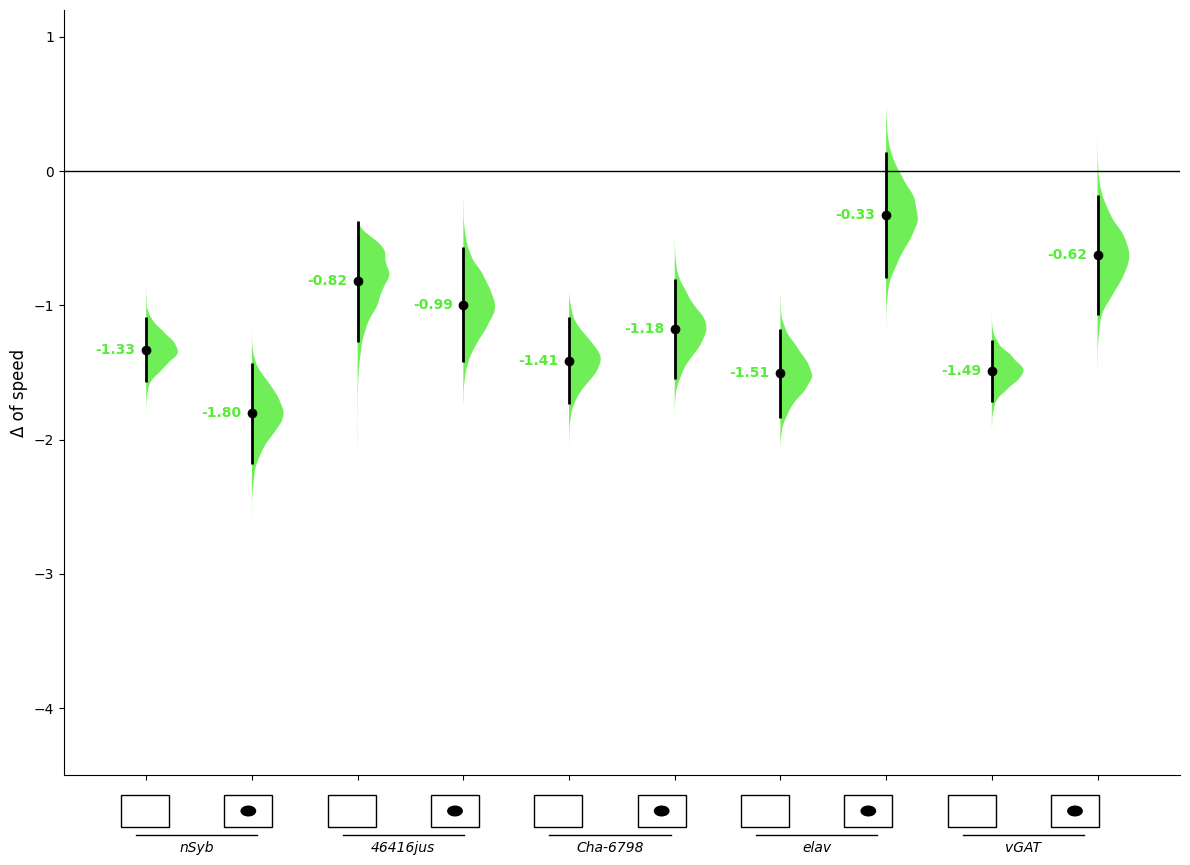

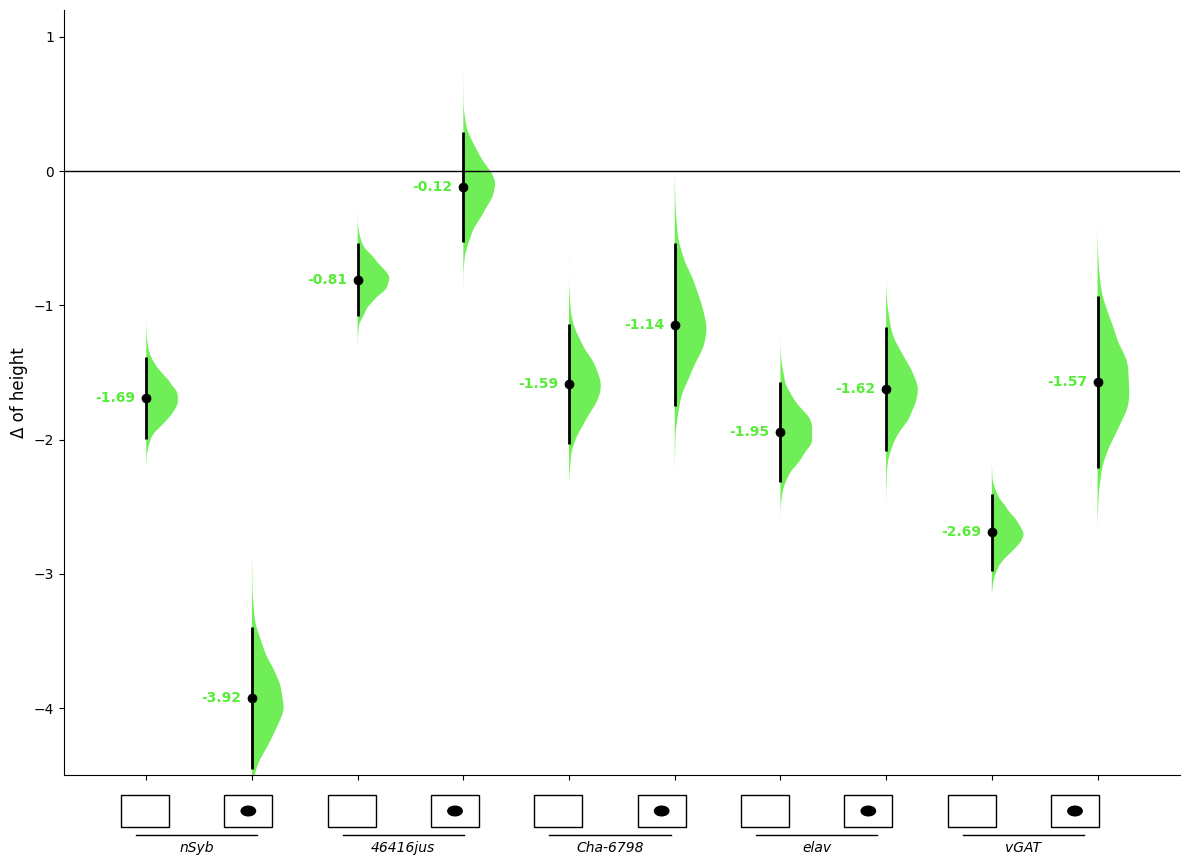

In [75]:
# colors = [["#FFD6EE", "#FFD6EE"], ["#FFD6EE", "#FFD6EE"], ["#FFD6EE", "#FFD6EE"],#rosepink
#           ['#DBF3FF', '#DBF3FF'], ['#DBF3FF', '#DBF3FF'] ]#pastelblue
                #yellow
            
#["#CDE5D9", "#CDE5D9"], ["#CDE5D9", "#CDE5D9"] #pastel green

# colors = [ ["#FFD6EE", "#FFD6EE"],
#         ['#DBF3FF', '#DBF3FF'],  #pastelblue
#         ["#F3F5A9", "#F3F5A9"],    #yellow
        
#         ]   

# colors = [ ["w", "w"],   ['w', 'w'],  ["w", "w"]]

colors = [ ["#F3F5A9", "#F3F5A9"],["#EBF13D", "#EBF13D"],
            ["#cbceee", "#cbceee"],["#a1a8f7", "#a1a8f7"],
            ["#F3F5A9", "#F3F5A9"], ["#EBF13D", "#EBF13D"],
            ["#cbceee", "#cbceee"],["#a1a8f7", "#a1a8f7"],
            ["#F3F5A9", "#F3F5A9"], ["#EBF13D", "#EBF13D"]]
    
for n in lstnamings:
    dfmn, dfsmd = pergenotypeplotting(openPath, files3, n)
    g = forestplot(dfmn, dfsmd, colors)
#    g.savefig(titledpath + "\\ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\eOPN3 manuscript\\Data Compilation\\Together\\images\\forestplot of TS_ER " + n + ".svg", bbox_inches="tight")   #change this filename where appropriate